### <font color='orange'> Task - 1: Data Loading and Preprocessing </font>:
1. Load the UCI Seeds dataset.
2. Check for missing values and duplicate rows in the dataset.
3. Handle any missing or duplicate data appropriately.

Marks Distribution:

1. Loading and displaying dataset: 
2. Checking and handling missing/duplicate data: 

In [19]:
# Import pandas library for data manipulation and analysis
import pandas as pd
# Import numpy for numerical operations and array handling
import numpy as np
# Import matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt
# Import KMeans clustering algorithm from scikit-learn
from sklearn.cluster import KMeans
# Import evaluation metrics for clustering performance
from sklearn.metrics import silhouette_score, adjusted_rand_score
# Import StandardScaler to normalize our data
from sklearn.preprocessing import StandardScaler
# Import seaborn for enhanced plotting capabilities
import seaborn as sns
# Import additional metrics for evaluating classification performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
# Import PCA for dimensionality reduction to create 2D plots
from sklearn.decomposition import PCA

# Define the URL where the seeds dataset is stored online
dataUrl = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
# Create a list of column names for our dataset features
columnNames = ['area', 'perimeter', 'compactness', 'lengthOfKernel', 'widthOfKernel',
                'asymmetryCoefficient', 'lengthOfGroove', 'species']

# Load the dataset from the URL into a pandas DataFrame
dataFrame = pd.read_csv(dataUrl, sep='\s+', names=columnNames, header=None)

# Print the dimensions of our dataset (rows and columns)
print("Dataset shape:", dataFrame.shape)
# Print a header for the next section
print("\nFirst few rows:")
# Display the first 5 rows of the dataset to see what it looks like
print(dataFrame.head())

# Print a header for dataset information
print("\nDataset info:")
# Show detailed information about each column including data types
print(dataFrame.info())

# Print a header for statistical summary
print("\nBasic statistics:")
# Calculate and display basic statistics like mean, std, min, max for each column
print(dataFrame.describe())

# Print a header for missing value analysis
print("\nMissing values:")
# Count how many missing values (NaN) are in each column
print(dataFrame.isnull().sum())

# Print a header for duplicate analysis
print(f"\nNumber of duplicate rows: {dataFrame.duplicated().sum()}")

# Check if there are any missing values in the entire dataset
if dataFrame.isnull().sum().sum() == 0:
    # If no missing values found, print confirmation message
    print("No missing values found in the dataset.")
else:
    # Remove all rows that contain missing values
    dataFrame = dataFrame.dropna()

# Check if there are any duplicate rows in the dataset
if dataFrame.duplicated().sum() > 0:
    # Remove all duplicate rows, keeping only the first occurrence
    dataFrame = dataFrame.drop_duplicates()
    # Print the new dataset size after removing duplicates
    print(f"Dataset shape after removing duplicates: {dataFrame.shape}")

# Separate the features (input variables) from the target (output variable)
featureData = dataFrame.drop('species', axis=1)
# Extract the target variable (species column) as a separate series
targetData = dataFrame['species']

# Print final dataset information after cleaning
print(f"\nFinal dataset shape: {dataFrame.shape}")
# Print the shape of our feature matrix
print(f"Features shape: {featureData.shape}")
# Print the shape of our target vector
print(f"Target shape: {targetData.shape}")
# Print all unique species values in the dataset
print(f"Unique species: {targetData.unique()}")
# Print how many samples belong to each species
print(f"Species distribution:\n{targetData.value_counts().sort_index()}")


<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-664938813.py:27: SyntaxWarning: invalid escape sequence '\s'
  dataFrame = pd.read_csv(dataUrl, sep='\s+', names=columnNames, header=None)


Dataset shape: (210, 8)

First few rows:
    area  perimeter  compactness  lengthOfKernel  widthOfKernel  \
0  15.26      14.84       0.8710           5.763          3.312   
1  14.88      14.57       0.8811           5.554          3.333   
2  14.29      14.09       0.9050           5.291          3.337   
3  13.84      13.94       0.8955           5.324          3.379   
4  16.14      14.99       0.9034           5.658          3.562   

   asymmetryCoefficient  lengthOfGroove  species  
0                 2.221           5.220        1  
1                 1.018           4.956        1  
2                 2.699           4.825        1  
3                 2.259           4.805        1  
4                 1.355           5.175        1  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  21

### <font color='orange'> Task - 2: K-Means Clustering Implementation from Scratch  </font>:

1. Implement the K-Means algorithm from scratch.
2. Use K-Means++ initialization to select initial centroids.
3. Perform clustering with 3 clusters.
4. Display the final cluster centroids and the number of samples in each cluster.

Marks Distribution:

1. Correct implementation of K-Means algorithm logic: 
2. Proper use of K-Means++ initialization:
3. Display and interpretation of results: 

In [20]:
# Define our custom K-Means clustering class that we'll build from scratch
class KMeansFromScratch:
    # Initialize the class with default parameters
    def __init__(self, numberOfClusters=3, maxIterations=100, randomSeed=42):
        # Store the number of clusters we want to create
        self.numberOfClusters = numberOfClusters
        # Store the maximum number of iterations to prevent infinite loops
        self.maxIterations = maxIterations
        # Store the random seed for reproducible results
        self.randomSeed = randomSeed
        # Initialize centroids as None (will be set during training)
        self.centroids = None
        # Initialize cluster labels as None (will be set during training)
        self.labels_ = None

    # Method to initialize centroids using K-Means++ algorithm
    def _kmeansPlusPlusInit(self, dataMatrix):
        # Set the random seed for reproducible results
        np.random.seed(self.randomSeed)
        # Get the number of samples and features in our data
        numberOfSamples, numberOfFeatures = dataMatrix.shape

        # Pick the first centroid randomly from our data points
        centroids = [dataMatrix[np.random.randint(numberOfSamples)]]

        # Pick the remaining centroids using distance-based probability
        for _ in range(self.numberOfClusters - 1):
            # Calculate minimum distance from each point to existing centroids
            distances = np.array([min([np.linalg.norm(point - center)**2 for center in centroids]) for point in dataMatrix])
            # Convert distances to probabilities (higher distance = higher probability)
            probabilities = distances / distances.sum()
            # Create cumulative probabilities for random selection
            cumulativeProbabilities = probabilities.cumsum()
            # Generate a random number between 0 and 1
            randomNumber = np.random.rand()

            # Find which point to select based on the random number
            for index, probability in enumerate(cumulativeProbabilities):
                if randomNumber < probability:
                    # Add the selected point as a new centroid
                    centroids.append(dataMatrix[index])
                    break

        # Return the centroids as a numpy array
        return np.array(centroids)

    # Method to assign each data point to its closest centroid
    def _assignClusters(self, dataMatrix, centroids):
        # Calculate distances from each point to each centroid
        distances = np.sqrt(((dataMatrix - centroids[:, np.newaxis])**2).sum(axis=2))
        # Return the index of the closest centroid for each point
        return np.argmin(distances, axis=0)

    # Method to update centroids based on current cluster assignments
    def _updateCentroids(self, dataMatrix, labels):
        # Create an array to store new centroid positions
        centroids = np.zeros((self.numberOfClusters, dataMatrix.shape[1]))
        # Update each centroid to be the mean of its assigned points
        for clusterIndex in range(self.numberOfClusters):
            # Calculate the mean of all points assigned to this cluster
            centroids[clusterIndex] = dataMatrix[labels == clusterIndex].mean(axis=0)
        # Return the updated centroids
        return centroids

    # Main method to train the K-Means model
    def fit(self, dataMatrix):
        # Initialize centroids using K-Means++ method
        self.centroids = self._kmeansPlusPlusInit(dataMatrix)

        # Run the K-Means algorithm for the specified number of iterations
        for iteration in range(self.maxIterations):
            # Store the previous cluster assignments for convergence check
            oldLabels = self.labels_ if self.labels_ is not None else None
            # Assign each point to its nearest centroid
            self.labels_ = self._assignClusters(dataMatrix, self.centroids)

            # Check if the algorithm has converged (no changes in assignments)
            if oldLabels is not None and np.array_equal(oldLabels, self.labels_):
                # Print convergence message and break the loop
                print(f"Converged after {iteration + 1} iterations")
                break

            # Update centroid positions based on new assignments
            self.centroids = self._updateCentroids(dataMatrix, self.labels_)

        # Return self to allow method chaining
        return self

    # Method to predict cluster assignments for new data
    def predict(self, dataMatrix):
        # Assign new points to clusters based on existing centroids
        return self._assignClusters(dataMatrix, self.centroids)

# Create a StandardScaler object to normalize our data
dataScaler = StandardScaler()
# Fit the scaler to our data and transform it to have mean=0 and std=1
scaledFeatureData = dataScaler.fit_transform(featureData)

# Create an instance of our custom K-Means class with 3 clusters
customKMeans = KMeansFromScratch(numberOfClusters=3, maxIterations=100, randomSeed=42)
# Train the model on our scaled data
customKMeans.fit(scaledFeatureData)

# Get the cluster assignments for each data point
customClusterLabels = customKMeans.labels_

# Print header for our custom implementation results
print("K-Means from Scratch Results:")
# Print the shape of our final centroids
print(f"Final centroids shape: {customKMeans.centroids.shape}")
# Print header for centroid values
print("\nFinal centroids:")
# Loop through each centroid and print its values
for index, centroid in enumerate(customKMeans.centroids):
    print(f"Cluster {index}: {centroid}")

# Print header for cluster size information
print(f"\nNumber of samples in each cluster:")
# Count how many points belong to each cluster
uniqueClusters, clusterCounts = np.unique(customClusterLabels, return_counts=True)
# Print the count for each cluster
for cluster, count in zip(uniqueClusters, clusterCounts):
    print(f"Cluster {cluster}: {count} samples")


Converged after 5 iterations
K-Means from Scratch Results:
Final centroids shape: (3, 7)

Final centroids:
Cluster 0: [ 1.22652173  1.23574863  0.532724    1.21993524  1.13038768 -0.04679182
  1.28020657]
Cluster 1: [-1.02721057 -0.99997026 -0.98626343 -0.88717757 -1.08668453  0.71802921
 -0.61335496]
Cluster 2: [-0.16711498 -0.20383953  0.47523925 -0.30265606 -0.01203069 -0.68216341
 -0.63980073]

Number of samples in each cluster:
Cluster 0: 69 samples
Cluster 1: 71 samples
Cluster 2: 70 samples


### <font color='orange'> Task - 3: Cluster Evaluation  </font>:

1. Evaluate the silhouette and Rand scores using scikit-learn functions.

Marks Distribution:

1. Correct computation of silhouette and Rand scores: 2 marks


In [21]:
# Evaluate the quality of our clustering results using different metrics
customSilhouetteScore = silhouette_score(scaledFeatureData, customClusterLabels)
# Print the silhouette score for our custom implementation
print(f"Silhouette Score (from-scratch): {customSilhouetteScore:.4f}")

# Calculate adjusted Rand index to compare our clusters with the true species labels
customRandIndex = adjusted_rand_score(targetData, customClusterLabels)
# Print the adjusted Rand index for our custom implementation
print(f"Adjusted Rand Index (from-scratch): {customRandIndex:.4f}")

# Print header for interpretation section
print("\nInterpretation:")
# Print the silhouette score with its range and interpretation
print(f"- Silhouette Score: {customSilhouetteScore:.4f}")
# Print the adjusted Rand index with its range and interpretation
print(f"- Adjusted Rand Index: {customRandIndex:.4f}")
# Determine and print the quality of cluster separation based on silhouette score
print(f"- Silhouette score indicates {'good' if customSilhouetteScore > 0.5 else 'moderate' if customSilhouetteScore > 0.2 else 'poor'} cluster separation")
# Determine and print the quality of agreement with ground truth based on Rand index
print(f"- Rand index indicates {'good' if customRandIndex > 0.5 else 'moderate' if customRandIndex > 0.2 else 'poor'} agreement with ground truth")


Silhouette Score (from-scratch): 0.4029
Adjusted Rand Index (from-scratch): 0.8112

Interpretation:
- Silhouette Score: 0.4029
- Adjusted Rand Index: 0.8112
- Silhouette score indicates moderate cluster separation
- Rand index indicates good agreement with ground truth


### <font color='orange'> Task - 4: Ground Truth Comparison and Label Assignment  </font>:

1. Using the ground truth labels available in the dataset, create a table showing how many samples of each true class fall into each cluster.
2. For each cluster, assign the majority class label to that cluster.
3. Compute accuracy, precision, and recall based on this assignment.

Marks Distribution:

1. Correct tabular comparison of clusters vs. true labels: 
2. Correct label assignment and metric computation: 

In [22]:
# Create a cross-tabulation table showing how many samples of each species fall into each cluster
comparisonTable = pd.crosstab(targetData, customClusterLabels, margins=True)
# Print header for the comparison table
print("Cluster vs True Label Comparison Table:")
# Display the comparison table
print(comparisonTable)

# Create a mapping from cluster numbers to their most common species labels
clusterToLabelMapping = {}
# Loop through each cluster to find its majority species
for clusterNumber in range(3):
    # Create a boolean mask to identify points belonging to this cluster
    clusterMask = customClusterLabels == clusterNumber
    # Get the true species labels for points in this cluster
    clusterTrueLabels = targetData[clusterMask]
    # Find the most common species in this cluster
    majorityLabel = clusterTrueLabels.mode()[0]
    # Store the mapping from cluster number to majority species
    clusterToLabelMapping[clusterNumber] = majorityLabel
    # Print which species is most common in this cluster
    print(f"\nCluster {clusterNumber} majority class: {majorityLabel}")

# Create predicted labels by assigning each cluster its most common species
predictedLabelsCustom = np.array([clusterToLabelMapping[cluster] for cluster in customClusterLabels])

# Calculate accuracy score (percentage of correct predictions)
customAccuracy = accuracy_score(targetData, predictedLabelsCustom)
# Calculate precision score (weighted average across all species)
customPrecision = precision_score(targetData, predictedLabelsCustom, average='weighted')
# Calculate recall score (weighted average across all species)
customRecall = recall_score(targetData, predictedLabelsCustom, average='weighted')

# Print header for performance metrics
print(f"\nPerformance Metrics (from-scratch):")
# Print the accuracy score
print(f"Accuracy: {customAccuracy:.4f}")
# Print the precision score
print(f"Precision: {customPrecision:.4f}")
# Print the recall score
print(f"Recall: {customRecall:.4f}")

# Create a confusion matrix to see where our predictions went wrong
confusionMatrixCustom = confusion_matrix(targetData, predictedLabelsCustom)
# Print header for confusion matrix
print(f"\nConfusion Matrix (from-scratch):")
# Display the confusion matrix
print(confusionMatrixCustom)


Cluster vs True Label Comparison Table:
col_0     0   1   2  All
species                 
1         2   5  63   70
2        67   0   3   70
3         0  66   4   70
All      69  71  70  210

Cluster 0 majority class: 2

Cluster 1 majority class: 3

Cluster 2 majority class: 1

Performance Metrics (from-scratch):
Accuracy: 0.9333
Precision: 0.9335
Recall: 0.9333

Confusion Matrix (from-scratch):
[[63  2  5]
 [ 3 67  0]
 [ 4  0 66]]


### <font color='orange'> Task - 5: Clustering using scikit-learn K-Means  </font>:

1. Perform clustering on the same dataset using scikit-learn’s KMeans with K-Means++ initialization and 3 clusters.
2. Compute silhouette score and Rand index.
3. Compare the results with your from-scratch implementation.

Marks Distribution:

1. Correct implementation and metric computation: 
2. Results Comparison: 

In [23]:
# Create a KMeans model with 3 clusters, K-Means++ initialization, and 10 random initializations
sklearnKMeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
# Train the sklearn KMeans model on our scaled data
sklearnKMeans.fit(scaledFeatureData)

# Get the cluster assignments from the trained sklearn model
sklearnClusterLabels = sklearnKMeans.labels_

# Calculate silhouette score for sklearn results
sklearnSilhouetteScore = silhouette_score(scaledFeatureData, sklearnClusterLabels)
# Calculate adjusted Rand index for sklearn results
sklearnRandIndex = adjusted_rand_score(targetData, sklearnClusterLabels)

# Print header for sklearn results
print("Scikit-learn K-Means Results:")
# Print the silhouette score from sklearn
print(f"Silhouette Score (sklearn): {sklearnSilhouetteScore:.4f}")
# Print the adjusted Rand index from sklearn
print(f"Adjusted Rand Index (sklearn): {sklearnRandIndex:.4f}")

# Print header for cluster size information
print(f"\nNumber of samples in each cluster (sklearn):")
# Count how many points belong to each sklearn cluster
uniqueSklearnClusters, sklearnClusterCounts = np.unique(sklearnClusterLabels, return_counts=True)
# Print the count for each sklearn cluster
for cluster, count in zip(uniqueSklearnClusters, sklearnClusterCounts):
    print(f"Cluster {cluster}: {count} samples")

# Print header for comparison section
print(f"\nComparison with from-scratch implementation:")
# Compare silhouette scores between custom and sklearn implementations
print(f"Silhouette Score - From-scratch: {customSilhouetteScore:.4f}, Sklearn: {sklearnSilhouetteScore:.4f}")
# Compare adjusted Rand indices between custom and sklearn implementations
print(f"Adjusted Rand Index - From-scratch: {customRandIndex:.4f}, Sklearn: {sklearnRandIndex:.4f}")

# Calculate the absolute difference in silhouette scores
silhouetteDifference = abs(customSilhouetteScore - sklearnSilhouetteScore)
# Calculate the absolute difference in Rand indices
randIndexDifference = abs(customRandIndex - sklearnRandIndex)

# Print header for differences section
print(f"\nDifferences:")
# Print the difference in silhouette scores
print(f"Silhouette score difference: {silhouetteDifference:.4f}")
# Print the difference in Rand indices
print(f"Rand index difference: {randIndexDifference:.4f}")

# Determine and print how similar the results are between implementations
if silhouetteDifference < 0.01 and randIndexDifference < 0.01:
    # If differences are very small, print that results are very similar
    print("Results are very similar between implementations!")
elif silhouetteDifference < 0.05 and randIndexDifference < 0.05:
    # If differences are small, print that results are reasonably similar
    print("Results are reasonably similar between implementations.")
else:
    # If differences are large, print that results show notable differences
    print("Results show notable differences between implementations.")


Scikit-learn K-Means Results:
Silhouette Score (sklearn): 0.4007
Adjusted Rand Index (sklearn): 0.7733

Number of samples in each cluster (sklearn):
Cluster 0: 72 samples
Cluster 1: 67 samples
Cluster 2: 71 samples

Comparison with from-scratch implementation:
Silhouette Score - From-scratch: 0.4029, Sklearn: 0.4007
Adjusted Rand Index - From-scratch: 0.8112, Sklearn: 0.7733

Differences:
Silhouette score difference: 0.0022
Rand index difference: 0.0379
Results are reasonably similar between implementations.


### <font color='orange'> Task - 6: Label Assignment and Evaluation for scikit-learn Clustering  </font>:

1. Repeat the majority class label assignment procedure for the clusters obtained from scikit-learn.
2. Compute accuracy, precision, and recall.
3. Compare these values with those from the from-scratch implementation.
4. Visualize the clusters (from-scratch and scikit-learn) using a 2D scatter plot with different colors for each cluster and mark the centroids.

Marks Distribution:

1. Correct label assignment and metric computation: 
2. Proper comparison and discussion: 
3. Visualization: 

Sklearn Cluster vs True Label Comparison Table:
col_0     0   1   2  All
species                 
1         6   2  62   70
2         0  65   5   70
3        66   0   4   70
All      72  67  71  210

Sklearn Cluster 0 majority class: 3

Sklearn Cluster 1 majority class: 2

Sklearn Cluster 2 majority class: 1

Performance Metrics Comparison:
Metric       From-scratch    Sklearn         Difference  
Accuracy     0.9333          0.9190          0.0143      
Precision    0.9335          0.9200          0.0135      
Recall       0.9333          0.9190          0.0143      


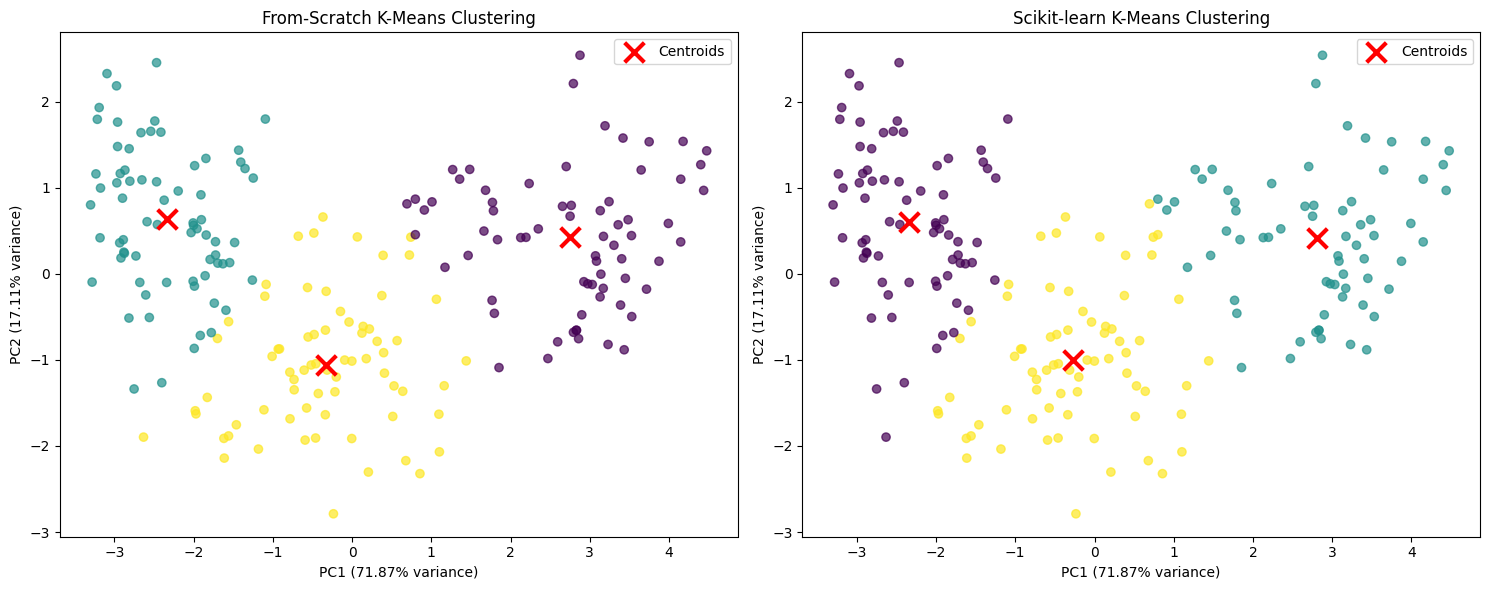


Visualization Summary:
- Both implementations show similar cluster patterns
- PCA explains 88.98% of total variance in 2D
- Red X markers indicate cluster centroids


In [24]:
# Create a cross-tabulation table for sklearn clusters with true species labels
sklearnComparisonTable = pd.crosstab(targetData, sklearnClusterLabels, margins=True)
# Print header for sklearn comparison table
print("Sklearn Cluster vs True Label Comparison Table:")
# Display the sklearn comparison table
print(sklearnComparisonTable)

# Create a mapping from sklearn cluster numbers to their most common species labels
sklearnClusterToLabelMapping = {}
# Loop through each sklearn cluster to find its majority species
for clusterNumber in range(3):
    # Create a boolean mask to identify points belonging to this sklearn cluster
    clusterMask = sklearnClusterLabels == clusterNumber
    # Get the true species labels for points in this sklearn cluster
    clusterTrueLabels = targetData[clusterMask]
    # Find the most common species in this sklearn cluster
    majorityLabel = clusterTrueLabels.mode()[0]
    # Store the mapping from sklearn cluster number to majority species
    sklearnClusterToLabelMapping[clusterNumber] = majorityLabel
    # Print which species is most common in this sklearn cluster
    print(f"\nSklearn Cluster {clusterNumber} majority class: {majorityLabel}")

# Create predicted labels for sklearn clusters by assigning each cluster its most common species
predictedLabelsSklearn = np.array([sklearnClusterToLabelMapping[cluster] for cluster in sklearnClusterLabels])

# Calculate accuracy score for sklearn results
sklearnAccuracy = accuracy_score(targetData, predictedLabelsSklearn)
# Calculate precision score for sklearn results
sklearnPrecision = precision_score(targetData, predictedLabelsSklearn, average='weighted')
# Calculate recall score for sklearn results
sklearnRecall = recall_score(targetData, predictedLabelsSklearn, average='weighted')

# Print header for performance metrics comparison
print(f"\nPerformance Metrics Comparison:")
# Print column headers for the comparison table
print(f"{'Metric':<12} {'From-scratch':<15} {'Sklearn':<15} {'Difference':<12}")
# Print accuracy comparison with differences
print(f"{'Accuracy':<12} {customAccuracy:<15.4f} {sklearnAccuracy:<15.4f} {abs(customAccuracy-sklearnAccuracy):<12.4f}")
# Print precision comparison with differences
print(f"{'Precision':<12} {customPrecision:<15.4f} {sklearnPrecision:<15.4f} {abs(customPrecision-sklearnPrecision):<12.4f}")
# Print recall comparison with differences
print(f"{'Recall':<12} {customRecall:<15.4f} {sklearnRecall:<15.4f} {abs(customRecall-sklearnRecall):<12.4f}")

# Create a PCA transformer to reduce our 7-dimensional data to 2 dimensions
pcaTransformer = PCA(n_components=2)
# Transform our scaled data to 2D using PCA
pcaTransformedData = pcaTransformer.fit_transform(scaledFeatureData)

# Create a figure with two subplots side by side
figure, plotAxes = plt.subplots(1, 2, figsize=(15, 6))

# Plot our custom clustering results on the left subplot
scatter1 = plotAxes[0].scatter(pcaTransformedData[:, 0], pcaTransformedData[:, 1], c=customClusterLabels, cmap='viridis', alpha=0.7)
# Set title for the left plot
plotAxes[0].set_title('From-Scratch K-Means Clustering')
# Set x-axis label with variance explained
plotAxes[0].set_xlabel(f'PC1 ({pcaTransformer.explained_variance_ratio_[0]:.2%} variance)')
# Set y-axis label with variance explained
plotAxes[0].set_ylabel(f'PC2 ({pcaTransformer.explained_variance_ratio_[1]:.2%} variance)')

# Plot sklearn clustering results on the right subplot
scatter2 = plotAxes[1].scatter(pcaTransformedData[:, 0], pcaTransformedData[:, 1], c=sklearnClusterLabels, cmap='viridis', alpha=0.7)
# Set title for the right plot
plotAxes[1].set_title('Scikit-learn K-Means Clustering')
# Set x-axis label with variance explained
plotAxes[1].set_xlabel(f'PC1 ({pcaTransformer.explained_variance_ratio_[0]:.2%} variance)')
# Set y-axis label with variance explained
plotAxes[1].set_ylabel(f'PC2 ({pcaTransformer.explained_variance_ratio_[1]:.2%} variance)')

# Transform custom centroids to PCA space for visualization
customCentroidsInPCA = pcaTransformer.transform(customKMeans.centroids)
# Transform sklearn centroids to PCA space for visualization
sklearnCentroidsInPCA = pcaTransformer.transform(sklearnKMeans.cluster_centers_)

# Add custom centroids to the left plot as red X markers
plotAxes[0].scatter(customCentroidsInPCA[:, 0], customCentroidsInPCA[:, 1],
               c='red', marker='x', s=200, linewidths=3, label='Centroids')
# Add sklearn centroids to the right plot as red X markers
plotAxes[1].scatter(sklearnCentroidsInPCA[:, 0], sklearnCentroidsInPCA[:, 1],
               c='red', marker='x', s=200, linewidths=3, label='Centroids')

# Add legend to the left plot
plotAxes[0].legend()
# Add legend to the right plot
plotAxes[1].legend()
# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plots
plt.show()

# Print header for visualization summary
print(f"\nVisualization Summary:")
# Print that both implementations show similar patterns
print(f"- Both implementations show similar cluster patterns")
# Print how much variance PCA explains in 2D
print(f"- PCA explains {pcaTransformer.explained_variance_ratio_.sum():.2%} of total variance in 2D")
# Print what the red X markers represent
print(f"- Red X markers indicate cluster centroids")
